# Digital Green -  Crop Yield Estimation Challenge

Smallholder farmers are crucial contributors to global food production, and in India often suffer most from poverty and malnutrition. These farmers face challenges such as limited access to modern agriculture, unpredictable weather, and resource constraints. To tackle this issue, Digital Green collected data via surveys, offering insights into farming practices, environmental conditions, and crop yields.

The objective of this challenge is to create a machine learning solution to predict the crop yield per acre of rice or wheat crops in India. Our goal is to empower these farmers and break the cycle of poverty and malnutrition.

A crop yield model could revolutionise Indian agriculture, and serve as a global model for smallholder farmers. Accurate yield predictions empower smallholder farmers to make informed planting and resource allocation decisions, reducing poverty and malnutrition and improving food security. As climate change intensifies, adaptive farming practices become crucial, making precise yield predictions even more valuable. Solutions developed here can drive sustainable agriculture and ensure a stable food supply for the world's growing population. This challenge offers data scientists and machine learning enthusiasts a unique chance to make a real difference in vulnerable populations' lives while advancing global food security in a concise, impactful way.

***Copied from Zindi Challenge***

GOALS

- predict crop yield per acre
- make informed planting and resource allocation decisions

## Load Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import missingno as msno
import seaborn as sns

In [40]:
#Load the dataset
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')
var_desc = pd.read_csv('VariableDescription.csv')
submission = pd.read_csv('SampleSubmission.csv')

### Data Cleaning & EDA

In [3]:
train_data.head()

,ID,District,Block,CultLand,CropCultLand,LandPreparationMethod,CropTillageDate,CropTillageDepth,CropEstMethod,RcNursEstDate,...,Harv_method,Harv_date,Harv_hand_rent,Threshing_date,Threshing_method,Residue_length,Residue_perc,Stubble_use,Acre,Yield
0,ID_GTFAC7PEVWQ9,Nalanda,Noorsarai,45,40,TractorPlough FourWheelTracRotavator,2022-07-20,5,Manual_PuddledRandom,2022-06-27,...,machine,2022-11-16,NaN,2022-11-16,machine,30,40,plowed_in_soil,0.312500,600
1,ID_TK40ARLSPOKS,Nalanda,Rajgir,26,26,WetTillagePuddling TractorPlough FourWheelTrac...,2022-07-18,5,Manual_PuddledRandom,2022-06-20,...,hand,2022-11-25,3.0,2022-12-24,machine,24,10,plowed_in_soil,0.312500,600
2,ID_1FJY2CRIMLZZ,Gaya,Gurua,10,10,TractorPlough FourWheelTracRotavator,2022-06-30,6,Manual_PuddledRandom,2022-06-20,...,hand,2022-12-12,480.0,2023-01-11,machine,30,10,plowed_in_soil,0.148148,225
3,ID_I3IPXS4DB7NE,Gaya,Gurua,15,15,TractorPlough FourWheelTracRotavator,2022-06-16,6,Manual_PuddledRandom,2022-06-17,...,hand,2022-12-02,240.0,2022-12-29,hand,26,10,plowed_in_soil,0.222222,468
4,ID_4T8YQWXWHB4A,Nalanda,Noorsarai,60,60,TractorPlough WetTillagePuddling,2022-07-19,4,Manual_PuddledRandom,2022-06-21,...,machine,2022-11-30,NaN,2022-12-02,machine,24,40,plowed_in_soil,0.468750,550


In [4]:
print(train_data["Yield"].describe())

count     3870.000000
mean       594.269251
std        651.916953
min          4.000000
25%        300.000000
50%        425.000000
75%        740.000000
max      16800.000000
Name: Yield, dtype: float64


In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3870 entries, 0 to 3869
Data columns (total 44 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   ID                                  3870 non-null   object 
 1   District                            3870 non-null   object 
 2   Block                               3870 non-null   object 
 3   CultLand                            3870 non-null   int64  
 4   CropCultLand                        3870 non-null   int64  
 5   LandPreparationMethod               3870 non-null   object 
 6   CropTillageDate                     3870 non-null   object 
 7   CropTillageDepth                    3870 non-null   int64  
 8   CropEstMethod                       3870 non-null   object 
 9   RcNursEstDate                       3787 non-null   object 
 10  SeedingSowingTransplanting          3870 non-null   object 
 11  SeedlingsPerPit                     3581 no

In [6]:
train_data.describe()

,CultLand,CropCultLand,CropTillageDepth,SeedlingsPerPit,TransplantingIrrigationHours,TransIrriCost,StandingWater,Ganaura,CropOrgFYM,NoFertilizerAppln,...,BasalUrea,1tdUrea,1appDaysUrea,2tdUrea,2appDaysUrea,Harv_hand_rent,Residue_length,Residue_perc,Acre,Yield
count,3870.000000,3870.000000,3870.000000,3581.000000,3677.000000,2988.000000,3632.000000,1453.000000,1196.000000,3870.000000,...,2166.000000,3314.000000,3314.000000,1176.000000,1170.000000,3618.000000,3870.000000,3870.000000,3870.000000,3870.000000
mean,28.527907,24.727132,4.488372,2.706507,8.017677,379.726908,3.247522,29.731590,57.445652,2.184496,...,13.351801,11.513881,29.200362,7.375000,58.764957,536.622443,26.517829,11.767442,0.292826,594.269251
std,30.454218,27.994802,1.133044,7.624397,42.612470,419.724782,2.207276,122.680882,328.251615,0.634632,...,9.701597,8.715856,12.139109,5.932502,11.356588,1138.613827,3.192873,7.064864,0.206918,651.916953
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,10.000000,0.045455,4.000000
25%,12.000000,10.000000,4.000000,2.000000,2.000000,150.000000,2.000000,1.000000,1.000000,2.000000,...,7.000000,6.000000,23.000000,4.000000,58.000000,150.000000,25.000000,10.000000,0.156250,300.000000
50%,20.000000,20.000000,4.000000,2.000000,4.000000,250.000000,3.000000,3.000000,2.000000,2.000000,...,10.000000,10.000000,28.000000,6.000000,60.000000,400.000000,26.000000,10.000000,0.227273,425.000000
75%,35.000000,30.000000,5.000000,3.000000,6.000000,450.000000,4.000000,4.000000,5.000000,3.000000,...,16.000000,15.000000,36.000000,10.000000,65.000000,700.000000,30.000000,10.000000,0.370370,740.000000
max,800.000000,800.000000,8.000000,442.000000,2000.000000,6000.000000,15.000000,1400.000000,4000.000000,4.000000,...,90.000000,90.000000,332.000000,67.000000,97.000000,60000.000000,30.000000,40.000000,2.187500,16800.000000


Drop ID and Post Harvest columns.

The goal is predict crop yield and help farmers make better planting decisions. That is my rationale for deleting Haverst columns. 

In [41]:
# drop columns that would not be needed
# we  may have to delete features that would not influence yields like post_harvet variables.

train_data = train_data.drop(columns=["ID"])

post_harvet variables.

- Harv_method
- Harv_date
- Harv_hand_rent
- Threshing_date
- Threshing_method
- Residue_length
- Residue_perc
- Stubble_use
- CropTilageDate: we don't need this


In [42]:
# Drop Post harvest features.

train_data = train_data.drop(columns=[
    "Harv_method",
    "Harv_date",
    "Harv_hand_rent",
    "Threshing_date",
    "Threshing_method",
    "Residue_length",
    "Residue_perc",
    "Stubble_use",
    "CropTillageDate"
])

Distribution of features

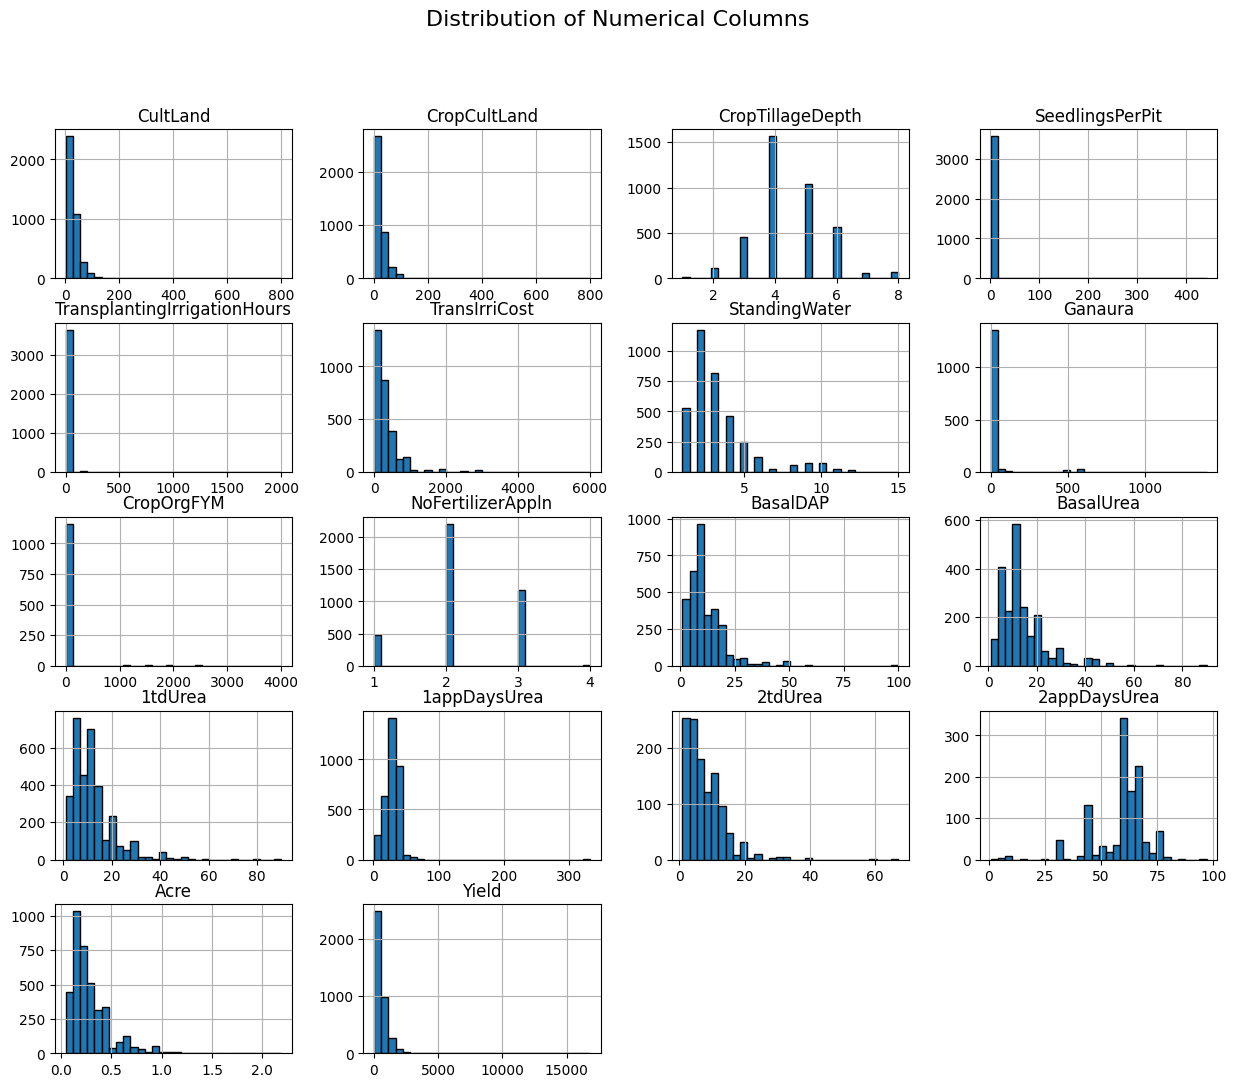

In [9]:
num_cols = train_data.select_dtypes(include=['int64', 'float64']).columns

# Plot histograms
train_data[num_cols].hist(figsize=(15, 12), bins=30, edgecolor="black")
plt.suptitle("Distribution of Numerical Columns", fontsize=16)
plt.show()

Check correlation

Text(0.5, 1.0, 'Correlation Heatmap')

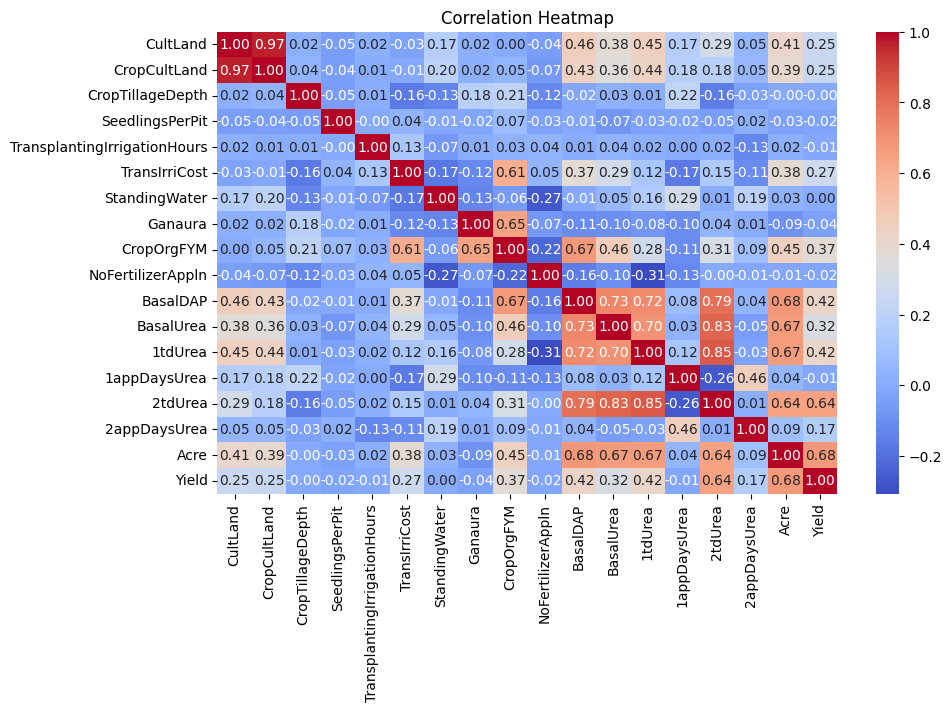

In [10]:
# correlation heatmap

plt.figure(figsize=(10, 6))
sns.heatmap(train_data[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")

Some features can be consolidated or re-engineered. 

### Analyze Cat variables

In [43]:
cat_cols = train_data.select_dtypes(include=["object"]).columns.tolist()

print(cat_cols)

['District', 'Block', 'LandPreparationMethod', 'CropEstMethod', 'RcNursEstDate', 'SeedingSowingTransplanting', 'NursDetFactor', 'TransDetFactor', 'TransplantingIrrigationSource', 'TransplantingIrrigationPowerSource', 'OrgFertilizers', 'PCropSolidOrgFertAppMethod', 'CropbasalFerts', 'MineralFertAppMethod', 'FirstTopDressFert', 'MineralFertAppMethod.1']


Check relationship between "NursDetFactor" & "TransDetFactor" & RcNursEstDate

In [44]:
train_data[
    train_data["NursDetFactor"].isna()
]["CropEstMethod"].value_counts(normalize=True) * 100

CropEstMethod
LineSowingAfterTillage    71.280277
Broadcasting              28.719723
Name: proportion, dtype: float64

In [45]:
train_data[
    train_data["TransDetFactor"].isna()
]["CropEstMethod"].value_counts(normalize=True) * 100

CropEstMethod
LineSowingAfterTillage    71.280277
Broadcasting              28.719723
Name: proportion, dtype: float64

In [46]:
train_data[
    train_data["RcNursEstDate"].isna()
]["CropEstMethod"].value_counts(normalize=True) * 100

CropEstMethod
Broadcasting    100.0
Name: proportion, dtype: float64

Missingness for "NursDetFactor" & "TransDetFactor" & RcNursEstDate are not Random

Check Irrigation variables

In [47]:
train_data[
    train_data["TransplantingIrrigationSource"].isna()
]["TransplantingIrrigationHours"].value_counts(normalize=True) * 100

Series([], Name: proportion, dtype: float64)

If no irrigation was done, then we don't have a Source or Power source, therefore no Cost associated with Irrigation. We will Impute accordingly below.

## Feature Engineering

Handle dates

In [48]:
train_data["RcNursEstDate"] = pd.to_datetime(
    train_data["RcNursEstDate"],
    errors="coerce"
)

train_data["SeedingSowingTransplanting"] = pd.to_datetime(
    train_data["SeedingSowingTransplanting"],
    errors="coerce"
)


train_data["NurseryStartMonth"] = train_data["RcNursEstDate"].dt.month
train_data['TransplantingMonth'] = train_data['SeedingSowingTransplanting'].dt.month

Drop the date columns

In [49]:
train_data.drop(columns=['RcNursEstDate', 'SeedingSowingTransplanting'],inplace=True)

I want to create a "Yield per Acre" column since that's the goal. I am not sure if I can do it post Model build - still thinkinh it through.

In [50]:
# create yield-per-acre
# keep Acre & Yield (Do not delete yet)

train_data["Yield_per_Acre"] = train_data["Yield"] / train_data["Acre"]

Fill the null values with ZERO and then we can create new variable

In [51]:
Urea_cols = ["BasalUrea", "1tdUrea", "2tdUrea"]

train_data[Urea_cols] = train_data[Urea_cols].fillna(0)

In [52]:
Fertilizer_cols = ["BasalDAP", "BasalUrea", "1tdUrea", "2tdUrea"]

train_data[Fertilizer_cols] = train_data[Fertilizer_cols].fillna(0)

In [53]:
train_data['TotalUrea'] = (
    train_data['BasalUrea'] +
    train_data['1tdUrea'] +
    train_data['2tdUrea']
)

In [54]:
train_data['TotalFertilizer'] = (
    train_data['BasalDAP'] +
    train_data['BasalUrea'] +
    train_data['1tdUrea'] +
    train_data['2tdUrea']
)

In [55]:
train_data = train_data.drop(
    columns=['BasalUrea', '1tdUrea', '2tdUrea']
)

In [56]:
# remove CultLand or CropCultLand

train_data = train_data.drop(columns=['CultLand'])

In [57]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3870 entries, 0 to 3869
Data columns (total 33 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   District                            3870 non-null   object 
 1   Block                               3870 non-null   object 
 2   CropCultLand                        3870 non-null   int64  
 3   LandPreparationMethod               3870 non-null   object 
 4   CropTillageDepth                    3870 non-null   int64  
 5   CropEstMethod                       3870 non-null   object 
 6   SeedlingsPerPit                     3581 non-null   float64
 7   NursDetFactor                       3581 non-null   object 
 8   TransDetFactor                      3581 non-null   object 
 9   TransplantingIrrigationHours        3677 non-null   float64
 10  TransplantingIrrigationSource       3755 non-null   object 
 11  TransplantingIrrigationPowerSource  3367 no

Text(0.5, 1.0, 'Correlation Heatmap')

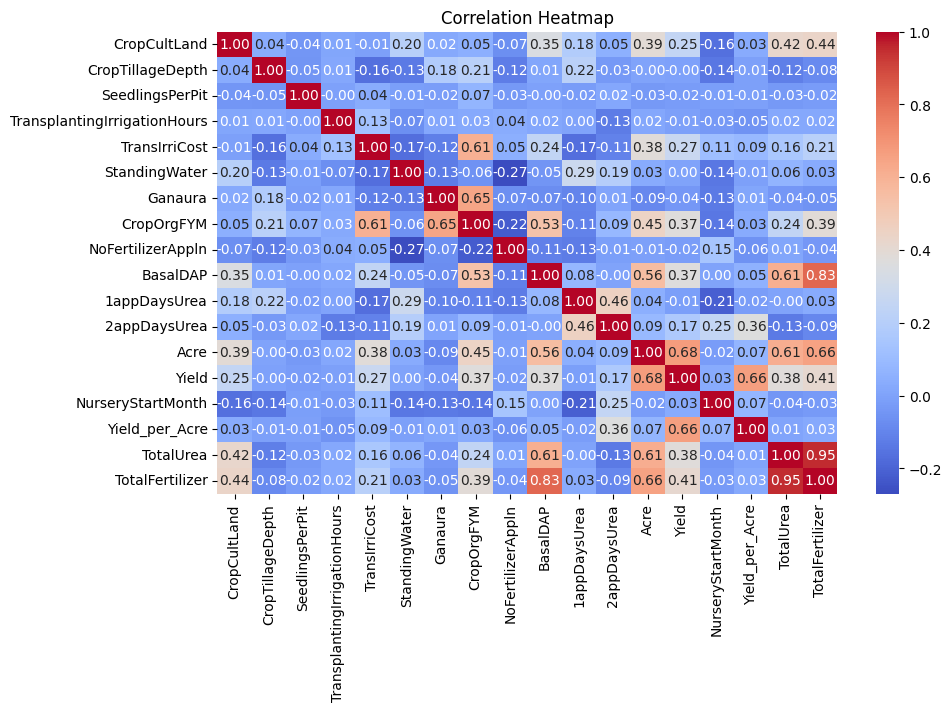

In [58]:
num_cols = train_data.select_dtypes(include=['int64', 'float64']).columns

# correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(train_data[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")

Handle missing values

In [59]:
train_data2 = train_data.copy()

<Axes: >

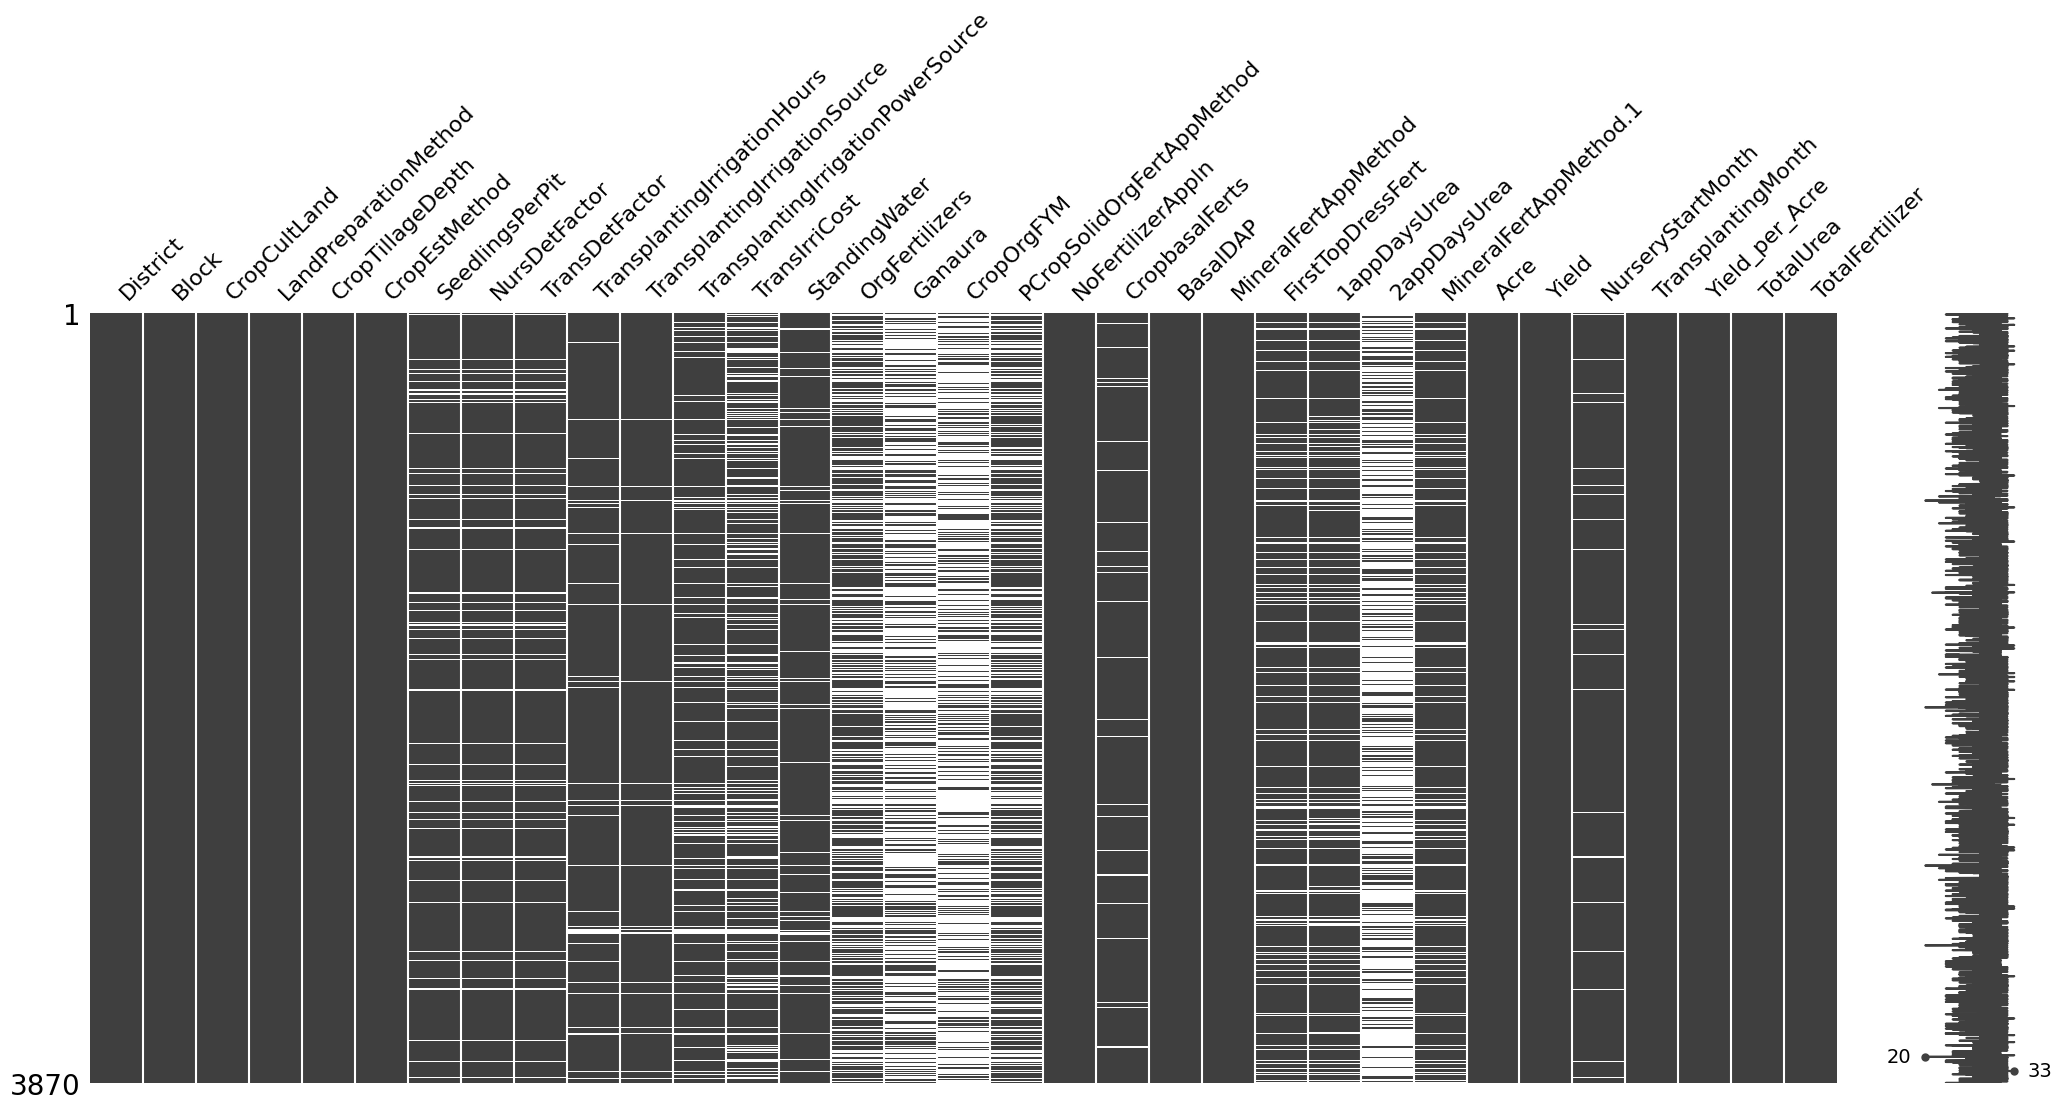

In [60]:
msno.matrix(train_data2)

In [61]:
train_data2['NurseryStartMonth'] = train_data2['NurseryStartMonth'].fillna(0)

In [62]:
train_data2["NursDetFactor"] = train_data2["NursDetFactor"].fillna(
    "Not applicable"
)

train_data2["TransDetFactor"] = train_data2["TransDetFactor"].fillna(
    "Not applicable"
)

In [63]:
#impute irrigation values

train_data2['TransIrriCost'] = train_data2['TransIrriCost'].fillna(0)

train_data2['TransplantingIrrigationPowerSource'] = train_data2['TransplantingIrrigationPowerSource'].fillna(
    'No irrigation'
    )

train_data2['TransplantingIrrigationHours'] = train_data2['TransplantingIrrigationHours'].fillna(0)

train_data2['TransplantingIrrigationSource'] = train_data2['TransplantingIrrigationSource'].fillna(
    'No irrigation'
    )

In [64]:
# other imputations

train_data2['1appDaysUrea'] = train_data2['1appDaysUrea'].fillna(0)
train_data2['SeedlingsPerPit'] = train_data2['SeedlingsPerPit'].fillna(0)

train_data2["StandingWater"] = train_data2["StandingWater"].fillna(
    train_data2["StandingWater"].median()
)

In [65]:
#impute missing values
train_data2['OrgFertilizers'] = train_data2['OrgFertilizers'].fillna('No organic fertilizer applied')
train_data2['Ganaura'] = train_data2['Ganaura'].fillna(0)
train_data2['CropOrgFYM'] = train_data2['CropOrgFYM'].fillna(0)
train_data2['PCropSolidOrgFertAppMethod'] = train_data2['PCropSolidOrgFertAppMethod'].fillna('No organic fertilizer applied')

In [66]:
missing_counts = train_data2.isnull().sum().sort_values(ascending=False)
print(missing_counts[missing_counts > 0])

2appDaysUrea              2700
FirstTopDressFert          485
MineralFertAppMethod.1     481
CropbasalFerts             188
dtype: int64


In [67]:
train_data2 = train_data2.drop(columns=["2appDaysUrea", "FirstTopDressFert", "MineralFertAppMethod.1",
                                      "CropbasalFerts"])

In [ ]:
# train_data.drop(columns=["NursDetFactor", "TransDetFactor",'RcNursEstDate',
#                          'SeedingSowingTransplanting'],inplace=True)

In [68]:
train_data2.isnull().sum()

District                              0
Block                                 0
CropCultLand                          0
LandPreparationMethod                 0
CropTillageDepth                      0
CropEstMethod                         0
SeedlingsPerPit                       0
NursDetFactor                         0
TransDetFactor                        0
TransplantingIrrigationHours          0
TransplantingIrrigationSource         0
TransplantingIrrigationPowerSource    0
TransIrriCost                         0
StandingWater                         0
OrgFertilizers                        0
Ganaura                               0
CropOrgFYM                            0
PCropSolidOrgFertAppMethod            0
NoFertilizerAppln                     0
BasalDAP                              0
MineralFertAppMethod                  0
1appDaysUrea                          0
Acre                                  0
Yield                                 0
NurseryStartMonth                     0


In [69]:
train_data2.head()

,District,Block,CropCultLand,LandPreparationMethod,CropTillageDepth,CropEstMethod,SeedlingsPerPit,NursDetFactor,TransDetFactor,TransplantingIrrigationHours,...,BasalDAP,MineralFertAppMethod,1appDaysUrea,Acre,Yield,NurseryStartMonth,TransplantingMonth,Yield_per_Acre,TotalUrea,TotalFertilizer
0,Nalanda,Noorsarai,40,TractorPlough FourWheelTracRotavator,5,Manual_PuddledRandom,2.0,CalendarDate IrrigWaterAvailability SeedAvaila...,CalendarDate SeedlingAge RainArrival IrrigWate...,5.0,...,0.0,Broadcasting,18.0,0.312500,600,6.0,7,1920.000000,35.0,35.0
1,Nalanda,Rajgir,26,WetTillagePuddling TractorPlough FourWheelTrac...,5,Manual_PuddledRandom,2.0,CalendarDate PreMonsoonShowers IrrigWaterAvail...,CalendarDate SeedlingAge RainArrival IrrigWate...,5.0,...,15.0,Broadcasting,39.0,0.312500,600,6.0,7,1920.000000,30.0,45.0
2,Gaya,Gurua,10,TractorPlough FourWheelTracRotavator,6,Manual_PuddledRandom,2.0,PreMonsoonShowers IrrigWaterAvailability Labou...,SeedlingAge IrrigWaterAvailability LaborAvaila...,4.0,...,4.0,SoilApplied,65.0,0.148148,225,6.0,8,1518.750000,5.0,9.0
3,Gaya,Gurua,15,TractorPlough FourWheelTracRotavator,6,Manual_PuddledRandom,2.0,CalendarDate PreMonsoonShowers IrrigWaterAvail...,CalendarDate SeedlingAge RainArrival IrrigWate...,0.0,...,6.0,Broadcasting,5.0,0.222222,468,6.0,7,2106.000000,8.0,14.0
4,Nalanda,Noorsarai,60,TractorPlough WetTillagePuddling,4,Manual_PuddledRandom,2.0,CalendarDate IrrigWaterAvailability SeedAvaila...,SeedlingAge RainArrival IrrigWaterAvailability...,9.0,...,15.0,Broadcasting,26.0,0.468750,550,6.0,7,1173.333333,60.0,75.0


In [70]:
cat_cols = train_data2.select_dtypes(
    include=["object", "category"]
).columns.tolist()

for col in cat_cols:
    print(col)

District
Block
LandPreparationMethod
CropEstMethod
NursDetFactor
TransDetFactor
TransplantingIrrigationSource
TransplantingIrrigationPowerSource
OrgFertilizers
PCropSolidOrgFertAppMethod
MineralFertAppMethod


In [71]:
#check unique value count

for col in cat_cols:
    print(f"\n{col}:")
    print(train_data2[col].nunique())


District:
4

Block:
9

LandPreparationMethod:
43

CropEstMethod:
4

NursDetFactor:
126

TransDetFactor:
156

TransplantingIrrigationSource:
7

TransplantingIrrigationPowerSource:
4

OrgFertilizers:
32

PCropSolidOrgFertAppMethod:
5

MineralFertAppMethod:
3


#following your lead here ***** low/high cardinality

In [72]:

cat_df=train_data2.select_dtypes(include=[object])
num_df=train_data2.select_dtypes(include=[np.number])

high_cardinality_cols = [col for col in cat_df.columns if cat_df[col].nunique() > 10]
low_cardinality_cols = [col for col in cat_df.columns if cat_df[col].nunique() <= 10]

In [73]:
#encode using one hot encoding for the low cardinality features
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)

encoded=ohe.fit_transform(cat_df[low_cardinality_cols].astype(str))
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(low_cardinality_cols))
encoded_df.head()

,District_Gaya,District_Jamui,District_Nalanda,District_Vaishali,Block_Chehrakala,Block_Garoul,Block_Gurua,Block_Jamui,Block_Khaira,Block_Mahua,...,TransplantingIrrigationPowerSource_No irrigation,TransplantingIrrigationPowerSource_Solar,PCropSolidOrgFertAppMethod_Broadcasting,PCropSolidOrgFertAppMethod_No organic fertilizer applied,PCropSolidOrgFertAppMethod_RootApplication,PCropSolidOrgFertAppMethod_SoilApplied,PCropSolidOrgFertAppMethod_Spray,MineralFertAppMethod_Broadcasting,MineralFertAppMethod_RootApplication,MineralFertAppMethod_SoilApplied
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [74]:
encoded_df=encoded_df.reset_index(drop=True)
num_df=num_df.reset_index(drop=True)
target_df=pd.DataFrame(cat_df[high_cardinality_cols])
target_df=target_df.reset_index(drop=True)
df2=pd.concat([num_df, encoded_df, target_df], axis=1)
df2.head()


,CropCultLand,CropTillageDepth,SeedlingsPerPit,TransplantingIrrigationHours,TransIrriCost,StandingWater,Ganaura,CropOrgFYM,NoFertilizerAppln,BasalDAP,...,PCropSolidOrgFertAppMethod_RootApplication,PCropSolidOrgFertAppMethod_SoilApplied,PCropSolidOrgFertAppMethod_Spray,MineralFertAppMethod_Broadcasting,MineralFertAppMethod_RootApplication,MineralFertAppMethod_SoilApplied,LandPreparationMethod,NursDetFactor,TransDetFactor,OrgFertilizers
0,40,5,2.0,5.0,200.0,2.0,0.0,0.0,2,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,TractorPlough FourWheelTracRotavator,CalendarDate IrrigWaterAvailability SeedAvaila...,CalendarDate SeedlingAge RainArrival IrrigWate...,No organic fertilizer applied
1,26,5,2.0,5.0,125.0,3.0,0.0,0.0,2,15.0,...,0.0,0.0,0.0,1.0,0.0,0.0,WetTillagePuddling TractorPlough FourWheelTrac...,CalendarDate PreMonsoonShowers IrrigWaterAvail...,CalendarDate SeedlingAge RainArrival IrrigWate...,No organic fertilizer applied
2,10,6,2.0,4.0,80.0,2.0,1.0,1.0,2,4.0,...,0.0,1.0,0.0,0.0,0.0,1.0,TractorPlough FourWheelTracRotavator,PreMonsoonShowers IrrigWaterAvailability Labou...,SeedlingAge IrrigWaterAvailability LaborAvaila...,Ganaura FYM
3,15,6,2.0,0.0,0.0,3.0,1.0,0.0,2,6.0,...,0.0,1.0,0.0,1.0,0.0,0.0,TractorPlough FourWheelTracRotavator,CalendarDate PreMonsoonShowers IrrigWaterAvail...,CalendarDate SeedlingAge RainArrival IrrigWate...,Ganaura
4,60,4,2.0,9.0,300.0,2.0,0.0,0.0,2,15.0,...,0.0,0.0,0.0,1.0,0.0,0.0,TractorPlough WetTillagePuddling,CalendarDate IrrigWaterAvailability SeedAvaila...,SeedlingAge RainArrival IrrigWaterAvailability...,No organic fertilizer applied


Split Data

In [75]:
X = df2.drop(['Yield'], axis=1)
y = df2['Yield']

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.20, random_state=20)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(3096, 57) (774, 57) (3096,) (774,)


*** Why don't we stratify in regression????

### Model Build

In [77]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import make_scorer, mean_squared_error, root_mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# Numerical Pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])


In [ ]:
# Categorical pipeline

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])


In [ ]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

Baseline model

In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])